In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


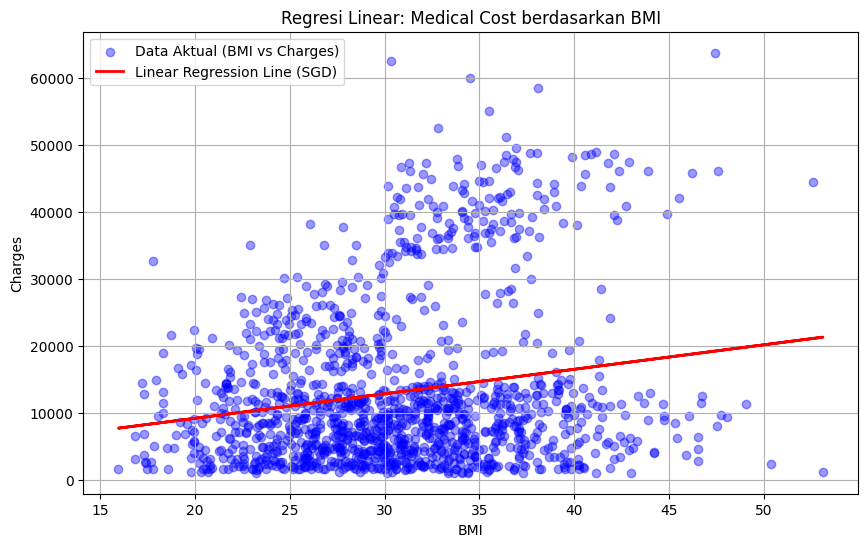

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path_file = '/content/drive/MyDrive/insurance.csv'
df = pd.read_csv(path_file)

x = df['bmi'].values
y = df['charges'].values

x_norm = (x - np.mean(x)) / np.std(x)
y_norm = (y - np.mean(y)) / np.std(y)

w = 0.0
b = 0.0
eta = 0.01
epochs = 100
n = len(x_norm)

for epoch in range(epochs):
    indices = np.random.permutation(n)

    for i in indices:
        x_i = x_norm[i]
        y_i = y_norm[i]

        f_x_i = w * x_i + b

        epsilon_i = f_x_i - y_i

        w = w - eta * epsilon_i * x_i
        b = b - eta * epsilon_i

y_pred_norm = w * x_norm + b
y_pred = y_pred_norm * np.std(y) + np.mean(y)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='blue', alpha=0.4, label='Data Aktual (BMI vs Charges)')

plt.plot(x, y_pred, color='red', linewidth=2, label='Linear Regression Line (SGD)')

plt.title('Regresi Linear: Medical Cost berdasarkan BMI')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()